In [18]:
!pip install pymannkendall

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


LSTM MODEL

In [20]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')

In [21]:
# Load data
try:
    filepath = '/content/drive/My Drive/Colab Notebooks/7084_source_data.csv'
    df = pd.read_csv(filepath)
except FileNotFoundError:
    print("Error: File not found. Please check the filepath.")
    exit(1)
except Exception as e:
    print(f"Error loading data: {e}")
    exit(1)

# Verify required columns exist
required_columns = ['srcStateName', 'srcYear', 'Station name'] + [
    col for pair in [
        ['Minimum potential of Hydrogen value in water', 'Maximum potential of Hydrogen value in water'],
        ['Minimum Conductivity Level', 'Maximum Conductivity Level'],
        ['Minimum Biochemical oxygen demand', 'Maximum Biochemical oxygen demand'],
        ['Minimum  of Nitrate N + Nitrite N required required for ground water',
         'Maximum  of Nitrate N + Nitrite N required required for ground water'],
        ['Minimum  of total coliform required for ground water',
         'Maximum  of total coliform required for ground water']
    ] for col in pair
]
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"Error: Missing required columns: {missing_cols}")
    exit(1)

In [22]:
# Filter for Goa and Maharashtra
df = df[df['srcStateName'].isin(['GOA', 'MAHARASHTRA'])]

# Check if any data remains after filtering
if df.empty:
    print("Error: No data found for Goa or Maharashtra.")
    exit(1)

# Data preprocessing
df['Year'] = df['srcYear']

# Extract district from Station name
def extract_district(station_name):
    if pd.isna(station_name):
        return 'Unknown'
    terms_to_remove = ['GROUND WATER', 'FROM', 'NEAR', 'RLY STATION', 'HS SCHOOL', 'COLLEGE', 'DISTRICT']
    name = station_name
    for term in terms_to_remove:
        name = name.replace(term, '').strip()
    return name.split('(')[0].split(',')[0].strip().title()

df['District'] = df['Station name'].apply(extract_district)

In [23]:
# Calculate average values for key parameters
parameters = {
    'Avg_pH': ['Minimum potential of Hydrogen value in water', 'Maximum potential of Hydrogen value in water'],
    'Avg_Conductivity': ['Minimum Conductivity Level', 'Maximum Conductivity Level'],
    'Avg_BOD': ['Minimum Biochemical oxygen demand', 'Maximum Biochemical oxygen demand'],
    'Avg_Nitrate': ['Minimum  of Nitrate N + Nitrite N required required for ground water',
                    'Maximum  of Nitrate N + Nitrite N required required for ground water'],
    'Avg_Total_Coliform': ['Minimum  of total coliform required for ground water',
                           'Maximum  of total coliform required for ground water']
}
for avg_col, (min_col, max_col) in parameters.items():
    df[avg_col] = (df[min_col] + df[max_col]) / 2

In [24]:
# Report missing values before imputation
print("\nMissing values before imputation:")
print(df[list(parameters.keys())].isna().sum())


Missing values before imputation:
Avg_pH                 2
Avg_Conductivity       2
Avg_BOD               10
Avg_Nitrate            1
Avg_Total_Coliform    46
dtype: int64


In [25]:
# Fill missing values
for avg_col in parameters.keys():
    # Linear interpolation within each district and state
    df[avg_col] = df.groupby(['srcStateName', 'District'])[avg_col].transform(lambda x: x.interpolate(method='linear'))
    # Fill remaining NaNs with district mean
    df[avg_col] = df.groupby(['srcStateName', 'District'])[avg_col].transform(lambda x: x.fillna(x.mean()))
    # Fill any remaining NaNs with state mean
    df[avg_col] = df.groupby('srcStateName')[avg_col].transform(lambda x: x.fillna(x.mean()))

# Report missing values after imputation
print("\nMissing values after imputation:")
print(df[list(parameters.keys())].isna().sum())

# Check if any missing values remain
if df[list(parameters.keys())].isna().any().any():
    print("Warning: Some missing values could not be filled. Dropping rows with remaining NaNs.")
    df = df.dropna(subset=list(parameters.keys()))


Missing values after imputation:
Avg_pH                0
Avg_Conductivity      0
Avg_BOD               0
Avg_Nitrate           0
Avg_Total_Coliform    0
dtype: int64


In [26]:
# Calculate Water Quality Trend Index (WQTI)
scaler = MinMaxScaler()
df['Norm_pH'] = scaler.fit_transform(df[['Avg_pH']])
df['Norm_Conductivity'] = scaler.fit_transform(df[['Avg_Conductivity']])
df['Norm_BOD'] = 1 - scaler.fit_transform(df[['Avg_BOD']])  # Invert: lower is better
df['Norm_Nitrate'] = 1 - scaler.fit_transform(df[['Avg_Nitrate']])  # Invert
df['Norm_Total_Coliform'] = 1 - scaler.fit_transform(df[['Avg_Total_Coliform']])  # Invert
df['WQTI'] = df[['Norm_pH', 'Norm_Conductivity', 'Norm_BOD', 'Norm_Nitrate', 'Norm_Total_Coliform']].mean(axis=1)

# Group by State, District, and Year for district-wise WQTI analysis
grouped_district = df.groupby(['srcStateName', 'District', 'Year'])['WQTI'].mean().reset_index()

# Mann-Kendall Test for District-wise WQTI (historical and predicted)
def perform_wqti_mk_test(data, district, state, is_predicted=False):
    try:
        result = mk.original_test(data['WQTI'])
        trend_value = 1 if result.trend == 'increasing' and result.p < 0.05 else -1 if result.trend == 'decreasing' and result.p < 0.05 else 0
        return pd.Series({
            'District': district,
            'State': state,
            'Trend': result.trend,
            'P-value': round(result.p, 4),
            'Slope': round(result.slope, 6),
            'Trend_Value': trend_value,
            'Last_WQTI': data['WQTI'].iloc[-1] if not is_predicted else np.nan,
            'Last_Year': data['Year'].iloc[-1] if not is_predicted else np.nan
        })
    except Exception as e:
        print(f"Error in Mann-Kendall test for {district}, {state} ({'predicted' if is_predicted else 'historical'}): {e}")
        return pd.Series({
            'District': district,
            'State': state,
            'Trend': 'no trend',
            'P-value': np.nan,
            'Slope': np.nan,
            'Trend_Value': 0,
            'Last_WQTI': data['WQTI'].iloc[-1] if not is_predicted and not data['WQTI'].empty else np.nan,
            'Last_Year': data['Year'].iloc[-1] if not is_predicted and not data['Year'].empty else np.nan
        })

In [27]:
# Function to prepare time-series data for LSTM
def prepare_lstm_data(data, time_steps=3):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)

# Function to build and train LSTM model
def train_lstm_model(X_train, y_train, time_steps):
    model = Sequential()
    model.add(LSTM(32, activation='relu', input_shape=(time_steps, 1), return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=4, verbose=0, callbacks=[EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)])
    return model

# Function to predict WQTI using LSTM
def predict_lstm(model, sequence, n_future, scaler):
    predictions = []
    current_sequence = sequence.copy()
    for _ in range(n_future):
        current_sequence_reshaped = current_sequence.reshape((1, len(current_sequence), 1))
        next_pred = model.predict(current_sequence_reshaped, verbose=0)
        predictions.append(next_pred[0, 0])
        current_sequence = np.roll(current_sequence, -1)
        current_sequence[-1] = next_pred[0, 0]
    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    return predictions.flatten()

# Calculate WQTI trends, collect WQTI values, and predict future years using LSTM
wqti_results = []
future_years = np.arange(2021, 2031)  # Predict 2026–2030
time_steps = 3  # Number of time steps for LSTM input
min_trend_points = 4  # Minimum points for Mann-Kendall test on predicted data
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

for state in ['Goa', 'Maharashtra']:
    state_district_data = grouped_district[grouped_district['srcStateName'] == state.upper()]
    for district in state_district_data['District'].unique():
        district_data = state_district_data[state_district_data['District'] == district]
        if len(district_data) > 1:  # Ensure enough data points for Mann-Kendall
            # Historical trend and WQTI values
            trend_result = perform_wqti_mk_test(district_data, district, state, is_predicted=False)
            for _, row in district_data.iterrows():
                result = trend_result.copy()
                result['Year'] = row['Year']
                result['WQTI'] = round(row['WQTI'], 4)
                result['Is_Predicted'] = False
                wqti_results.append(result)

            # Predictions for future years
            if len(district_data) >= time_steps + 1:  # Ensure enough data for LSTM
                try:
                    # Prepare data for LSTM
                    wqti_values = district_data['WQTI'].values.reshape(-1, 1)
                    scaler = MinMaxScaler()
                    wqti_scaled = scaler.fit_transform(wqti_values)
                    X, y = prepare_lstm_data(wqti_scaled, time_steps)
                    if len(X) > 0:  # Ensure enough data to train
                        # Train LSTM model
                        model = train_lstm_model(X, y, time_steps)
                        # Predict future WQTI
                        last_sequence = wqti_scaled[-time_steps:]
                        future_wqti = predict_lstm(model, last_sequence, len(future_years), scaler)  # Fixed: predict_future_lstm -> predict_lstm
                        # Create a DataFrame for predicted values
                        predicted_data = pd.DataFrame({
                            'Year': future_years,
                            'WQTI': future_wqti
                        })
                        predicted_data['WQTI'] = predicted_data['WQTI'].clip(0, 1)
                        # Calculate predicted trend
                        if len(predicted_data) >= min_trend_points and np.std(predicted_data['WQTI']) > 1e-6:
                            predicted_trend = perform_wqti_mk_test(predicted_data, district, state, is_predicted=True)
                        else:
                            predicted_trend = pd.Series({
                                'District': district,
                                'State': state,
                                'Trend': 'no trend',
                                'P-value': np.nan,
                                'Slope': np.nan,
                                'Trend_Value': 0
                            })
                        for _, row in predicted_data.iterrows():
                            result = predicted_trend.copy()
                            result['Year'] = row['Year']
                            result['WQTI'] = round(row['WQTI'], 4)
                            result['Is_Predicted'] = True
                            wqti_results.append(result)
                    else:
                        # Fallback to last WQTI if insufficient data
                        for year in future_years:
                            result = trend_result.copy()
                            result['Year'] = year
                            result['WQTI'] = round(trend_result['Last_WQTI'], 4)
                            result['Is_Predicted'] = True
                            result['Trend'] = 'no trend'
                            result['P-value'] = np.nan
                            result['Slope'] = np.nan
                            result['Trend_Value'] = 0
                            wqti_results.append(result)
                except Exception as e:
                    print(f"Error in LSTM prediction for {district}, {state}: {e}")
                    # Fallback to last WQTI if LSTM fails
                    for year in future_years:
                        result = trend_result.copy()
                        result['Year'] = year
                        result['WQTI'] = round(trend_result['Last_WQTI'], 4)
                        result['Is_Predicted'] = True
                        result['Trend'] = 'no trend'
                        result['P-value'] = np.nan
                        result['Slope'] = np.nan
                        result['Trend_Value'] = 0
                        wqti_results.append(result)
            else:
                # Fallback to last WQTI if insufficient data points
                for year in future_years:
                    result = trend_result.copy()
                    result['Year'] = year
                    result['WQTI'] = round(trend_result['Last_WQTI'], 4)
                    result['Is_Predicted'] = True
                    result['Trend'] = 'no trend'
                    result['P-value'] = np.nan
                    result['Slope'] = np.nan
                    result['Trend_Value'] = 0
                    wqti_results.append(result)

wqti_results_df = pd.DataFrame(wqti_results)


In [28]:
# Display separate tables for historical and predicted WQTI values and trends
# Historical Table
historical_df = wqti_results_df[wqti_results_df['Is_Predicted'] == False]
if not historical_df.empty:
    print('\nDistrict-wise Historical WQTI and Trend Analysis Table:')
    print(historical_df[['State', 'District', 'Year', 'WQTI', 'Trend', 'P-value', 'Slope']].sort_values(['State', 'District', 'Year']).to_string(index=False))


District-wise Historical WQTI and Trend Analysis Table:
      State                                                                District   Year   WQTI      Trend  P-value     Slope
        Goa                                  Bore Well At Bethora Industrial Estate 2016.0 0.6544   no trend   0.7341  0.010314
        Goa                                  Bore Well At Bethora Industrial Estate 2017.0 0.6176   no trend   0.7341  0.010314
        Goa                                  Bore Well At Bethora Industrial Estate 2018.0 0.6420   no trend   0.7341  0.010314
        Goa                                  Bore Well At Bethora Industrial Estate 2019.0 0.6606   no trend   0.7341  0.010314
        Goa                                 Bore Well At Cuncolim Industrial Estate 2016.0 0.6681   no trend   0.3082  0.013547
        Goa                                 Bore Well At Cuncolim Industrial Estate 2017.0 0.6569   no trend   0.3082  0.013547
        Goa                                 Bor

In [29]:
# Predicted Table
predicted_df = wqti_results_df[wqti_results_df['Is_Predicted'] == True]
if not predicted_df.empty:
    print('\nDistrict-wise Predicted WQTI and Trend Analysis Table (2026–2030):')
    print(predicted_df[['State', 'District', 'Year', 'WQTI', 'Trend', 'P-value', 'Slope']].sort_values(['State', 'District', 'Year']).to_string(index=False))


District-wise Predicted WQTI and Trend Analysis Table (2026–2030):
      State                                                                District   Year   WQTI      Trend  P-value     Slope
        Goa                                  Bore Well At Bethora Industrial Estate 2021.0 0.6240 decreasing   0.0001 -0.000317
        Goa                                  Bore Well At Bethora Industrial Estate 2022.0 0.6238 decreasing   0.0001 -0.000317
        Goa                                  Bore Well At Bethora Industrial Estate 2023.0 0.6226 decreasing   0.0001 -0.000317
        Goa                                  Bore Well At Bethora Industrial Estate 2024.0 0.6209 decreasing   0.0001 -0.000317
        Goa                                  Bore Well At Bethora Industrial Estate 2025.0 0.6207 decreasing   0.0001 -0.000317
        Goa                                  Bore Well At Bethora Industrial Estate 2026.0 0.6205 decreasing   0.0001 -0.000317
        Goa                         

In [30]:
# Time-Series Plots for WQTI per District (with predictions)
for state in ['Goa', 'Maharashtra']:
    state_district_data = wqti_results_df[wqti_results_df['State'] == state]
    for district in state_district_data['District'].unique():
        district_data = state_district_data[state_district_data['District'] == district]
        if len(district_data[district_data['Is_Predicted'] == False]) > 1:  # Ensure enough historical points
            plt.figure(figsize=(10, 5))
            # Plot historical data
            historical = district_data[district_data['Is_Predicted'] == False]
            plt.plot(historical['Year'], historical['WQTI'], marker='o', color='blue', label='Historical WQTI')
            # Plot predicted data
            predicted = district_data[district_data['Is_Predicted'] == True]
            if not predicted.empty:
                plt.plot(predicted['Year'], predicted['WQTI'], marker='x', linestyle='--', color='orange', label='Predicted WQTI')
            plt.title(f'WQTI Trend in {district}, {state}')
            plt.xlabel('Year')
            plt.ylabel('WQTI (0 to 1)')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

Output hidden; open in https://colab.research.google.com to view.

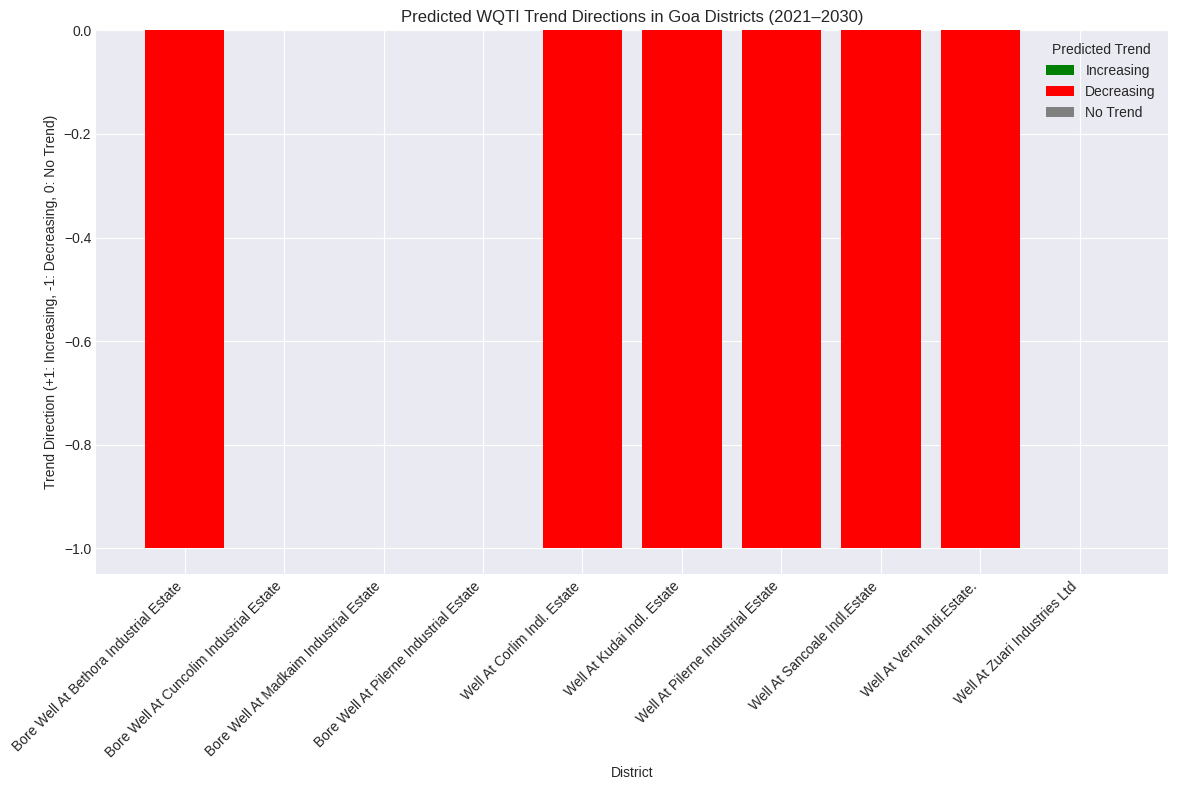


Predicted WQTI Trend Details for Goa (2026–2030):
                               District      Trend  P-value     Slope
 Bore Well At Bethora Industrial Estate decreasing   0.0004 -0.000314
Bore Well At Cuncolim Industrial Estate   no trend   0.1203  0.000000
 Bore Well At Madkaim Industrial Estate   no trend   1.0000  0.000000
 Bore Well At Pilerne Industrial Estate   no trend   1.0000  0.000000
            Well At Corlim Indl. Estate decreasing   0.0194 -0.000038
             Well At Kudai Indl. Estate decreasing   0.0011 -0.000117
      Well At Pilerne Industrial Estate decreasing   0.0004 -0.000200
           Well At Sancoale Indl.Estate decreasing   0.0437  0.000000
             Well At Verna Indi.Estate. decreasing   0.0437  0.000000
           Well At Zuari Industries Ltd   no trend   1.0000  0.000000


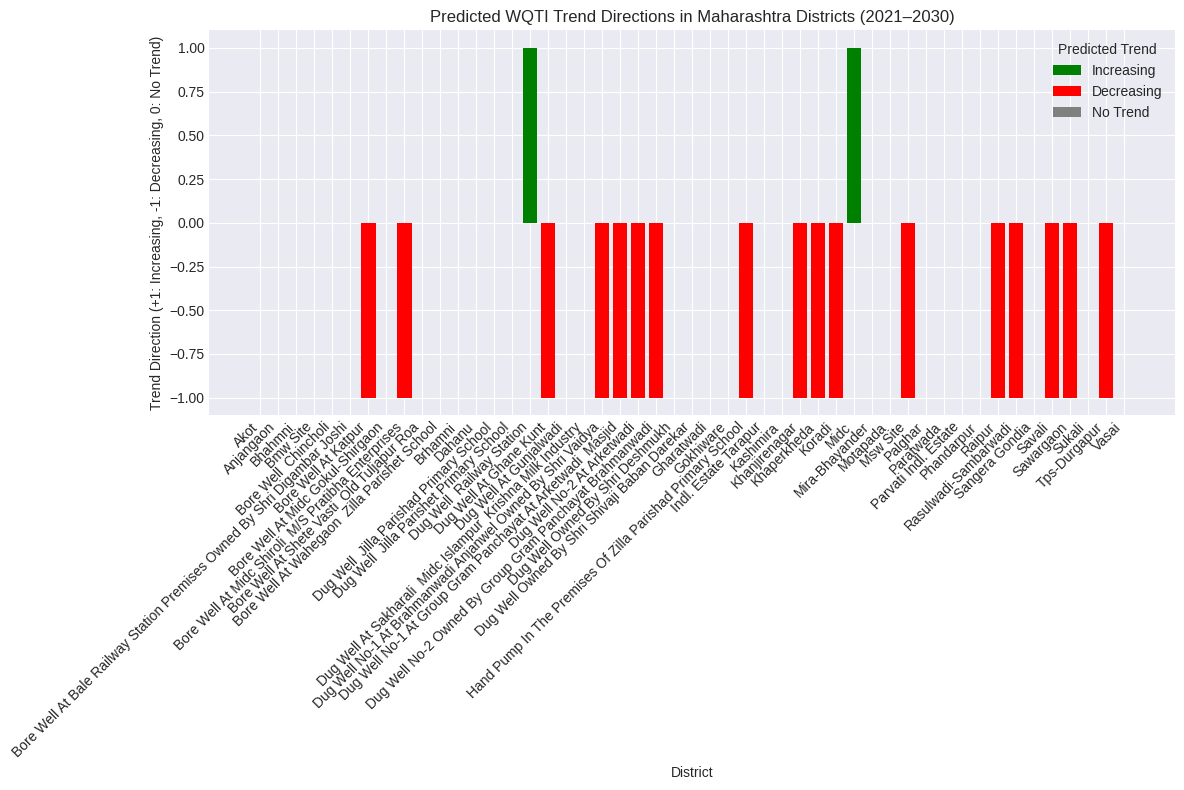


Predicted WQTI Trend Details for Maharashtra (2026–2030):
                                                               District      Trend  P-value     Slope
                                                                   Akot   no trend   1.0000  0.000000
                                                              Anjangaon   no trend   1.0000  0.000000
                                                                Bhahmni   no trend   1.0000  0.000000
                                                               Bmw Site   no trend   1.0000  0.000000
                                                   Bore Well  Chincholi   no trend   1.0000  0.000000
Bore Well At Bale Railway Station Premises Owned By Shri Digambar Joshi   no trend   1.0000  0.000000
                                                    Bore Well At Katpur decreasing   0.0008 -0.000250
                                       Bore Well At Midc Gokul-Shirgaon   no trend   1.0000  0.000000
                    Bor

In [31]:

# Bar Charts for District-wise Predicted WQTI Trends
from matplotlib.patches import Patch

for state in ['Goa', 'Maharashtra']:
    state_data = wqti_results_df[(wqti_results_df['State'] == state) & (wqti_results_df['Is_Predicted'] == True)]
    if not state_data.empty:
        # Calculate trends for predicted WQTI values per district
        trend_results = []
        for district in state_data['District'].unique():
            district_data = state_data[state_data['District'] == district]
            if len(district_data) >= 2:  # Need at least 2 points for Mann-Kendall
                trend_result = perform_wqti_mk_test(district_data, district, state, is_predicted=True)
                trend_results.append({
                    'District': district,
                    'State': state,
                    'Trend_Value': trend_result['Trend_Value'],
                    'Trend': trend_result['Trend'],
                    'Slope': trend_result['Slope'],
                    'P-value': trend_result['P-value']
                })
        trend_df = pd.DataFrame(trend_results)

        if not trend_df.empty:
            plt.figure(figsize=(12, 8))
            colors = ['green' if x == 1 else 'red' if x == -1 else 'gray' for x in trend_df['Trend_Value']]
            bars = plt.bar(trend_df['District'], trend_df['Trend_Value'], color=colors)
            plt.title(f'Predicted WQTI Trend Directions in {state} Districts (2021–2030)')
            plt.xlabel('District')
            plt.ylabel('Trend Direction (+1: Increasing, -1: Decreasing, 0: No Trend)')
            plt.xticks(rotation=45, ha='right')
            plt.grid(True, axis='y')
            # Add legend
            legend_elements = [
                Patch(facecolor='green', label='Increasing'),
                Patch(facecolor='red', label='Decreasing'),
                Patch(facecolor='gray', label='No Trend')
            ]
            plt.legend(handles=legend_elements, title='Predicted Trend')
            plt.tight_layout()
            plt.show()

            # Print trend details for verification
            print(f"\nPredicted WQTI Trend Details for {state} (2026–2030):")
            print(trend_df[['District', 'Trend', 'P-value', 'Slope']].to_string(index=False))

# **Linear Regression**

In [33]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymannkendall as mk
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set plot style (use a valid style for newer Matplotlib versions)
plt.style.use('seaborn-v0_8-darkgrid')

# Load data
try:
    filepath = '/content/drive/My Drive/Colab Notebooks/7084_source_data.csv'
    df = pd.read_csv(filepath)
except FileNotFoundError:
    print("Error: File not found. Please check the filepath.")
    exit(1)
except Exception as e:
    print(f"Error loading data: {e}")
    exit(1)

# Verify required columns exist
required_columns = ['srcStateName', 'srcYear', 'Station name'] + [
    col for pair in [
        ['Minimum potential of Hydrogen value in water', 'Maximum potential of Hydrogen value in water'],
        ['Minimum Conductivity Level', 'Maximum Conductivity Level'],
        ['Minimum Biochemical oxygen demand', 'Maximum Biochemical oxygen demand'],
        ['Minimum  of Nitrate N + Nitrite N required required for ground water',
         'Maximum  of Nitrate N + Nitrite N required required for ground water'],
        ['Minimum  of total coliform required for ground water',
         'Maximum  of total coliform required for ground water']
    ] for col in pair
]
missing_cols = [col for col in required_columns if col not in df.columns]
if missing_cols:
    print(f"Error: Missing required columns: {missing_cols}")
    exit(1)

# Filter for Goa and Maharashtra (assuming dataset uses uppercase)
df = df[df['srcStateName'].isin(['GOA', 'MAHARASHTRA'])]

# Check if any data remains after filtering
if df.empty:
    print("Error: No data found for Goa or Maharashtra.")
    exit(1)

# Data preprocessing
df['Year'] = df['srcYear']

# Extract district from Station name
def extract_district(station_name):
    if pd.isna(station_name):
        return 'Unknown'
    terms_to_remove = ['GROUND WATER', 'FROM', 'NEAR', 'RLY STATION', 'HS SCHOOL', 'COLLEGE', 'DISTRICT']
    name = station_name
    for term in terms_to_remove:
        name = name.replace(term, '').strip()
    return name.split('(')[0].split(',')[0].strip().title()

df['District'] = df['Station name'].apply(extract_district)

# Calculate average values for key parameters
parameters = {
    'Avg_pH': ['Minimum potential of Hydrogen value in water', 'Maximum potential of Hydrogen value in water'],
    'Avg_Conductivity': ['Minimum Conductivity Level', 'Maximum Conductivity Level'],
    'Avg_BOD': ['Minimum Biochemical oxygen demand', 'Maximum Biochemical oxygen demand'],
    'Avg_Nitrate': ['Minimum  of Nitrate N + Nitrite N required required for ground water',
                    'Maximum  of Nitrate N + Nitrite N required required for ground water'],
    'Avg_Total_Coliform': ['Minimum  of total coliform required for ground water',
                           'Maximum  of total coliform required for ground water']
}
for avg_col, (min_col, max_col) in parameters.items():
    df[avg_col] = (df[min_col] + df[max_col]) / 2

# Report missing values before imputation
print("\nMissing values before imputation:")
print(df[list(parameters.keys())].isna().sum())

# Fill missing values
for avg_col in parameters.keys():
    # Linear interpolation within each district and state
    df[avg_col] = df.groupby(['srcStateName', 'District'])[avg_col].transform(lambda x: x.interpolate(method='linear'))
    # Fill remaining NaNs with district mean
    df[avg_col] = df.groupby(['srcStateName', 'District'])[avg_col].transform(lambda x: x.fillna(x.mean()))
    # Fill any remaining NaNs with state mean
    df[avg_col] = df.groupby('srcStateName')[avg_col].transform(lambda x: x.fillna(x.mean()))

# Report missing values after imputation
print("\nMissing values after imputation:")
print(df[list(parameters.keys())].isna().sum())

# Check if any missing values remain
if df[list(parameters.keys())].isna().any().any():
    print("Warning: Some missing values could not be filled. Dropping rows with remaining NaNs.")
    df = df.dropna(subset=list(parameters.keys()))

# Calculate Water Quality Trend Index (WQTI)
scaler = MinMaxScaler()
df['Norm_pH'] = scaler.fit_transform(df[['Avg_pH']])
df['Norm_Conductivity'] = scaler.fit_transform(df[['Avg_Conductivity']])
df['Norm_BOD'] = 1 - scaler.fit_transform(df[['Avg_BOD']])  # Invert: lower is better
df['Norm_Nitrate'] = 1 - scaler.fit_transform(df[['Avg_Nitrate']])  # Invert
df['Norm_Total_Coliform'] = 1 - scaler.fit_transform(df[['Avg_Total_Coliform']])  # Invert
df['WQTI'] = df[['Norm_pH', 'Norm_Conductivity', 'Norm_BOD', 'Norm_Nitrate', 'Norm_Total_Coliform']].mean(axis=1)

# Group by State, District, and Year for district-wise WQTI analysis
grouped_district = df.groupby(['srcStateName', 'District', 'Year'])['WQTI'].mean().reset_index()

# Mann-Kendall Test for District-wise WQTI
def perform_wqti_mk_test(data, district, state):
    try:
        result = mk.original_test(data['WQTI'])
        trend_value = 1 if result.trend == 'increasing' and result.p < 0.05 else -1 if result.trend == 'decreasing' and result.p < 0.05 else 0
        return pd.Series({
            'District': district,
            'State': state,
            'Trend': result.trend,
            'P-value': round(result.p, 4),
            'Slope': round(result.slope, 6),
            'Trend_Value': trend_value,
            'Last_WQTI': data['WQTI'].iloc[-1],
            'Last_Year': data['Year'].iloc[-1]
        })
    except Exception as e:
        print(f"Error in Mann-Kendall test for {district}, {state}: {e}")
        return pd.Series({
            'District': district,
            'State': state,
            'Trend': 'no trend',
            'P-value': np.nan,
            'Slope': np.nan,
            'Trend_Value': 0,
            'Last_WQTI': data['WQTI'].iloc[-1] if not data['WQTI'].empty else np.nan,
            'Last_Year': data['Year'].iloc[-1] if not data['Year'].empty else np.nan
        })

# Function to train linear regression model and predict future WQTI
def train_predict_linear_regression(data, future_years):
    try:
        X = data['Year'].values.reshape(-1, 1)
        y = data['WQTI'].values
        model = LinearRegression()
        model.fit(X, y)
        future_X = np.array(future_years).reshape(-1, 1)
        future_predictions = model.predict(future_X)
        # Clip predictions to [0, 1] to match WQTI range
        future_predictions = np.clip(future_predictions, 0, 1)
        return future_predictions
    except Exception as e:
        print(f"Error in linear regression for {data['District'].iloc[0]}, {data['srcStateName'].iloc[0]}: {e}")
        return None

# Calculate WQTI trends, collect WQTI values, and predict future years using linear regression
wqti_results = []
future_years = np.arange(2021, 2031)  # Predict 2026–2030

for state in ['Goa', 'Maharashtra']:
    state_district_data = grouped_district[grouped_district['srcStateName'] == state.upper()]
    for district in state_district_data['District'].unique():
        district_data = state_district_data[state_district_data['District'] == district]
        if len(district_data) > 1:  # Ensure enough data points for Mann-Kendall
            trend_result = perform_wqti_mk_test(district_data, district, state)
            # Add historical WQTI values
            for _, row in district_data.iterrows():
                result = trend_result.copy()
                result['Year'] = row['Year']
                result['WQTI'] = round(row['WQTI'], 4)
                result['Is_Predicted'] = False
                wqti_results.append(result)
            # Linear regression-based predictions
            if len(district_data) >= 2:  # Ensure enough data for linear regression
                future_wqti = train_predict_linear_regression(district_data, future_years)
                if future_wqti is not None:
                    # Add predicted WQTI values
                    for year, pred_wqti in zip(future_years, future_wqti):
                        result = trend_result.copy()
                        result['Year'] = year
                        result['WQTI'] = round(pred_wqti, 4)
                        result['Is_Predicted'] = True
                        wqti_results.append(result)
                else:
                    # Fallback to last WQTI if linear regression fails
                    for year in future_years:
                        result = trend_result.copy()
                        result['Year'] = year
                        result['WQTI'] = round(trend_result['Last_WQTI'], 4)
                        result['Is_Predicted'] = True
                        wqti_results.append(result)
            else:
                # Fallback to last WQTI if insufficient data points
                for year in future_years:
                    result = trend_result.copy()
                    result['Year'] = year
                    result['WQTI'] = Rounds(trend_result['Last_WQTI'], 4)
                    result['Is_Predicted'] = True
                    wqti_results.append(result)

wqti_results_df = pd.DataFrame(wqti_results)

# Display table of WQTI values and trends (historical and predicted)
print('\nDistrict-wise WQTI and Trend Analysis Table (Historical and Predicted):')
print(wqti_results_df[['State', 'District', 'Year', 'WQTI', 'Trend', 'P-value', 'Slope', 'Is_Predicted']].sort_values(['State', 'District', 'Year']).to_string(index=False))

# Time-Series Plots for WQTI per District (with predictions)
for state in ['Goa', 'Maharashtra']:
    state_district_data = wqti_results_df[wqti_results_df['State'] == state]
    for district in state_district_data['District'].unique():
        district_data = state_district_data[state_district_data['District'] == district]
        if len(district_data[district_data['Is_Predicted'] == False]) > 1:  # Ensure enough historical points
            plt.figure(figsize=(10, 5))
            # Plot historical data
            historical = district_data[district_data['Is_Predicted'] == False]
            plt.plot(historical['Year'], historical['WQTI'], marker='o', color='blue', label='Historical WQTI')
            # Plot predicted data
            predicted = district_data[district_data['Is_Predicted'] == True]
            if not predicted.empty:
                plt.plot(predicted['Year'], predicted['WQTI'], marker='x', linestyle='--', color='orange', label='Predicted WQTI (Linear Regression)')
            plt.title(f'WQTI Trend in {district}, {state}')
            plt.xlabel('Year')
            plt.ylabel('WQTI (0 to 1)')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

Output hidden; open in https://colab.research.google.com to view.